## Convolutional Networks

We'll check out how to build a **convolutional network** to classify CIFAR10 images. By using weight sharing - multiple units with the same weights - convolutional layers are able to learn repeated patterns in your data. For example, a unit could learn the pattern for an eye, or a face, or lower level features like edges.


In [27]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import numpy as np
import time

import torch
from torch import nn
from torch import optim
import torch.nn.functional as F
import torch.utils.data as utils
from torchvision import datasets, transforms
from torch.utils.data.sampler import SubsetRandomSampler
import matplotlib.pyplot as plt
import torchvision.utils as vutils
from torchvision.datasets import CIFAR10

%matplotlib inline

In [3]:
label_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]


def plot_images(images, cls_true, cls_pred=None):
    """
    Adapted from https://github.com/Hvass-Labs/TensorFlow-Tutorials/
    """
    fig, axes = plt.subplots(3, 3)

    for i, ax in enumerate(axes.flat):
        # plot img
        ax.imshow(images[i, :, :, :], interpolation='spline16')

        # show true & predicted classes
        cls_true_name = label_names[cls_true[i]]
        if cls_pred is None:
            xlabel = "{0} ({1})".format(cls_true_name, cls_true[i])
        else:
            cls_pred_name = label_names[cls_pred[i]]
            xlabel = "True: {0}\nPred: {1}".format(
                cls_true_name, cls_pred_name
            )
        ax.set_xlabel(xlabel)
        ax.set_xticks([])
        ax.set_yticks([])

    plt.show()

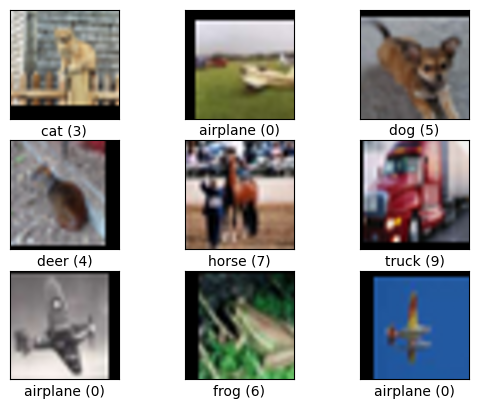

In [32]:
def get_train_valid_loader(data_dir='content/data',
                           batch_size=64,
                           augment=False,
                           random_seed=1,
                           valid_size=0.02,
                           shuffle=True,
                           show_sample=True,
                           num_workers=2,
                           pin_memory=False):
    """
    Utility function for loading and returning train and valid
    multi-process iterators over the CIFAR-10 dataset. A sample
    9x9 grid of the images can be optionally displayed.
    If using CUDA, num_workers should be set to 1 and pin_memory to True.
    Params
    ------
    - data_dir: path directory to the dataset.
    - batch_size: how many samples per batch to load.
    - augment: whether to apply the data augmentation scheme
      mentioned in the paper. Only applied on the train split.
    - random_seed: fix seed for reproducibility.
    - valid_size: percentage split of the training set used for
      the validation set. Should be a float in the range [0, 1].
    - shuffle: whether to shuffle the train/validation indices.
    - show_sample: plot 9x9 sample grid of the dataset.
    - num_workers: number of subprocesses to use when loading the dataset.
    - pin_memory: whether to copy tensors into CUDA pinned memory. Set it to
      True if using GPU.
    Returns
    -------
    - train_loader: training set iterator.
    - valid_loader: validation set iterator.
    """
    error_msg = "[!] valid_size should be in the range [0, 1]."
    assert ((valid_size >= 0) and (valid_size <= 1)), error_msg

    normalize = transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465],
        std=[0.2023, 0.1994, 0.2010],
    )

    # define transforms for validation (no augmentation)
    valid_transform = transforms.Compose([
        transforms.ToTensor(),
        normalize,
    ])

    # Define the transform for training (and data augmentation)

    train_transform = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomCrop(size=32, padding=4),
        transforms.ToTensor(),
        normalize
    ])

    # load the dataset
    train_dataset = datasets.CIFAR10(
        root=data_dir, train=True,
        download=True, transform=train_transform,
    )

    valid_dataset = datasets.CIFAR10(
        root=data_dir, train=True,
        download=True, transform=valid_transform,
    )

    num_train = len(train_dataset)
    indices = list(range(num_train))
    split = int(np.floor(valid_size * num_train))

    if shuffle:
        np.random.seed(random_seed)
        np.random.shuffle(indices)

    train_idx, valid_idx = indices[split:], indices[:split]
    train_sampler = SubsetRandomSampler(train_idx)
    valid_sampler = SubsetRandomSampler(valid_idx)

    train_loader = torch.utils.data.DataLoader(
        train_dataset, batch_size=batch_size, sampler=train_sampler,
        num_workers=num_workers, pin_memory=pin_memory,
    )
    valid_loader = torch.utils.data.DataLoader(
        valid_dataset, batch_size=batch_size, sampler=valid_sampler,
        num_workers=num_workers, pin_memory=pin_memory,
    )

    # visualize some images if requested
    if show_sample:
        sample_loader = torch.utils.data.DataLoader(
            train_dataset, batch_size=9, shuffle=shuffle,
            num_workers=num_workers, pin_memory=pin_memory,
        )
        data_iter = iter(sample_loader)
        images, labels = next(data_iter)
        # Unnormalize the images for display
        mean = [0.4914, 0.4822, 0.4465]
        std = [0.2023, 0.1994, 0.2010]
        unnorm_images = [unnormalize(img, mean, std) for img in images]
        X = torch.stack(unnorm_images).numpy().transpose([0, 2, 3, 1])
        plot_images(X, labels)

    return (train_loader, valid_loader)

def unnormalize(img, mean, std):
    img = img * torch.tensor(std).view(3, 1, 1) + torch.tensor(mean).view(3, 1, 1)
    return img

trainloader, valloader = get_train_valid_loader()

# Convolutional Neural Network Architecture

Let's first talk about the overall architecture of a CNN and how each dimension evolves after each layer, we'll take as example the first and famous CNN LeNet5 :
<figure align="center">
  <img src="https://doimages.nyc3.cdn.digitaloceanspaces.com/010AI-ML/content/images/2021/10/image-17.png" alt="LeNet5 Architecture" width="600">
  <figcaption>Image credit: <a href="https://en.wikipedia.org">Wikipedia</a></figcaption>
</figure>

For that, we will have some quick questions to see if you understand what happens during training/inference:

### 1. First Layer Convolution

If we consider the input of LeNet5 to be CIFAR-10, what would be the shape of the parameters of the first convolutional layer (stride = 1)?
- **A.** `torch.Size([6, 1, 5, 5])`
- **B.** `torch.Size([6, 3, 3, 3])`
- **C.** `torch.Size([6, 1, 5, 5])`
- **D.** `torch.Size([6, 3, 5, 5])`


-> Answer : D

Because we have 6 output chanel and 3 input chanel therefore [6,3,K,K], 6 filters of size 3xKxK. For the kernek size we know our input size of 32x32 and output size of 28x28 so using the following formula we find K=5 (with a padding of 0, P=0, and a stride of 1, S=1):

$$
W_{out} = \frac{W_{in} - K - 2\cdot P}{S} + 1
$$


---

### 2. Subsampling Window

What is the shape of the subsampling window (stride = 2) for the second layer (between C1 and C2), and does this shape remain invariant regardless of the subsampling method (e.g., Avg pooling or Max pooling)?

- **A.** `2x2, yes it does`
- **B.** `3x3, no it doesn't`
- **C.** `2x2, no it doesn't`
- **D.** `yes, it does`

-> Answer : A

Using the same formula as previsously with $W_{in} = 28$, $W_{out} = 14$, $S = 2$, $P=0$ we find $K =2$. And as we can see with the formula the method used for the pooling wheter it's taking the maximum or the average value inside the filter, it won't affect the output size if we keep the same parameters for the filter.


---

### 3. Backpropagation for Convolutional Filters

Do the filters in the convolutional layers also benefit from backpropagation?

-> Answer :

Yes, because even if they are shared parameters they are parameters that are learned during the training process, therefore the gradient of the loss is also computed with respect to these weights. And in the update step they are also updated accordingly to theire gradient (using the optimization method chosed).

---

### 4. Role of the Fully-Connected Layer

Explain in your own words why it is necessary to have a fully-connected layer in the architecture.

-> Answer : 

The fully connected is there to be sure that every features are taken into account for the computation of the final score. A convolutional layer mainly learns more local patterns in the image, while the fully connected connects them all together to have a global representation of the input characteristics. And as each neuron has a specific receptive field, the fully connected layers ensure that the final output consider the whole input. The two parts can be seen as the convolutional one as understanding the features and then the fully connected as the classifier using the extracted features.

---
If you had any struggle to answer one of theses questions, feel free to ask a TA about intuition or hints about the solution.

# Build your own Convolutional Neural Network Architecture

## Different ways to improve the accuracy of your network :
- Change the number of convolutions and layers (you can take inspiration from internet as you as you cite the architecture)
- Change the optmizer / its hyperparameters
- Add new types of layers
- Do some data augmentation in the get_train_valid_loader function (flipped, cropped, uncentered images) cf. https://pytorch.org/vision/stable/transforms.html


---

## My methodologie

- Some very basic data augmentation was made to have more training data and prevent overfitting, I added some random cropping and horizontal flip.
- For the architecture of my Neural network, the strucure of LeNet5 was followed and recreated. It's composed of 2 convolutional layers each followed wby a max-pooling layers. And finally 3 fully conneted layers were added decreasing the dimensions between each one. And aditionally, after testing and obtaining a better accuracy, batch normalization layers were added after each convolutional layers and before the activation function, which is a common practice in CNN models. For every convolutional and fully connected layers the activation fontion used was the ReLU.
- Then the the learning rate hyperparameter was tuned using the validation set. Several candidate (common values) were tested by computing the accuracy on the validation set after a small training process.
- Finally, the training process was performed using the best learning rate. 

In [33]:
class ConvNet(nn.Module):
    def __init__(self, n_input_channels=3, n_output=10):
        super().__init__()
        ################################################################################
        # TODO:                                                                        #
        # Define 2 or more different layers of the neural network                      #
        ################################################################################
        self.conv1 = torch.nn.Conv2d(in_channels=n_input_channels, out_channels= 6, kernel_size=5, stride=1)
        self.norm1 = torch.nn.BatchNorm2d(6)
        self.pool1 = torch.nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = torch.nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, stride=1)
        self.norm2 = torch.nn.BatchNorm2d(16)
        self.pool2 = torch.nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = torch.nn.Linear(400, 120)
        self.fc2 = torch.nn.Linear(120, 84)
        self.fc3 = torch.nn.Linear(84, n_output)
        ################################################################################
        #                              END OF YOUR CODE                                #
        ################################################################################

    def forward(self, x):
        ################################################################################
        # TODO:                                                                        #
        # Set up the forward pass that the input data will go through.                 #
        # A good activation function betweent the layers is a ReLu function.           #
        #                                                                              #
        # Note that the output of the last convolution layer should be flattened       #
        # before being inputted to the fully connected layer. We can flatten           #
        # Tensor `x` with `x.view`.                                                    #
        ################################################################################
        x = F.relu(self.norm1(self.conv1(x)))
        x = self.pool1(x)
        x = F.relu(self.norm2(self.conv2(x)))
        x = self.pool2(x)
        x = x.view(x.size(0),-1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        ################################################################################
        #                              END OF YOUR CODE                                #
        ################################################################################

        return x

    def predict(self, x):
        logits = self.forward(x)
        return F.softmax(logits, dim=1)

In [34]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = torch.nn.CrossEntropyLoss()

learning_rates = [0.00001, 0.0001, 0.001, 0.01, 0.05, 0.1, 0.25, 0.5] 

epoch_val = 3
val_acc = []

for lr in learning_rates:
    print(f'---- lr = {lr} ----')
    net = ConvNet().to(device)
    optimizer = torch.optim.Adam(net.parameters(), lr=lr)  # Choose the optimizer you want and tune its hyperparameter
    for e in range(epoch_val):
        net.train()
        for images, labels in iter(trainloader):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            output = net(images)
            loss = criterion(output, labels)
            loss.backward()
            optimizer.step()

    net.eval()
    with torch.no_grad():
        correct = 0
        total = 0
        for data in valloader:
            images, labels = data
            images, labels = images.to(device), labels.to(device)
            outputs = net(images)
            _, predicted = torch.max(outputs.data, dim=1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            acc = 100 * (correct/total)


    print(f'Validation accuracy : {acc:.4g}%')
    val_acc.append(acc)

best_lr = learning_rates[np.argmax(val_acc)]
print(f'Best learning rate : {best_lr}')

---- lr = 1e-05 ----
Validation accuracy : 33.2%
---- lr = 0.0001 ----
Validation accuracy : 47%
---- lr = 0.001 ----
Validation accuracy : 59.8%
---- lr = 0.01 ----
Validation accuracy : 55.2%
---- lr = 0.05 ----
Validation accuracy : 20.8%
---- lr = 0.1 ----
Validation accuracy : 10.5%
---- lr = 0.25 ----
Validation accuracy : 10.6%
---- lr = 0.5 ----
Validation accuracy : 8.8%
Best learning rate : 0.001


In [35]:
net = ConvNet().to(device)
################################################################################
# TODO:                                                                        #
# Choose an Optimizer that will be used to minimize the loss function.         #
# Choose a critera that measures the loss                                      #
################################################################################
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(net.parameters(), lr = best_lr)

epochs = 10
steps = 0
running_loss = 0
print_every = 20
for e in range(epochs):
    net.train()
    start = time.time()
    for images, labels in iter(trainloader):
        images, labels = images.to(device), labels.to(device)
        steps += 1
        ################################################################################
        # TODO:                                                                        #
        # Run the training process                                                     #
        #                                                                              #
        ################################################################################
        optimizer.zero_grad()
        output = net(images)
        ################################################################################
        #                              END OF YOUR CODE                                #
        ################################################################################
        loss = criterion(output, labels)
        ################################################################################
        # TODO:                                                                        #
        # Run the training process                                                     #
        #                                                                              #
        # HINT: Calculate the gradient and move one step further                       #
        ################################################################################
        loss.backward()
        optimizer.step()
        ################################################################################
        #                              END OF YOUR CODE                                #
        ################################################################################

        running_loss += loss.item()

        if steps % print_every == 0:
            net.eval()
            stop = time.time()
            # Test accuracy
            correct = 0
            total = 0
            for ii, (images, labels) in enumerate(valloader):
                images, labels = images.to(device), labels.to(device)
                ################################################################################
                # TODO:                                                                        #
                # Calculate the accuracy                                                       #
                ################################################################################
                outputs = net(images)
                _, predicted = torch.max(outputs.data, dim=1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                ################################################################################
                #                              END OF YOUR CODE                                #
                ################################################################################
            accuracy = 100*(correct/total)
            print("Epoch: {}/{}..".format(e+1, epochs),
                  "Loss: {:.4f}..".format(running_loss/print_every),
                  "Test accuracy: {:.4g}..".format(accuracy),
                  "{:.4f} s/batch".format((stop - start)/print_every)
                 )
            net.train()
            running_loss = 0
            start = time.time()

Epoch: 1/10.. Loss: 2.2211.. Test accuracy: 24.8.. 0.0240 s/batch
Epoch: 1/10.. Loss: 2.0092.. Test accuracy: 25.8.. 0.0180 s/batch
Epoch: 1/10.. Loss: 1.8779.. Test accuracy: 31.6.. 0.0191 s/batch
Epoch: 1/10.. Loss: 1.8328.. Test accuracy: 31.9.. 0.0189 s/batch
Epoch: 1/10.. Loss: 1.8569.. Test accuracy: 31.6.. 0.0182 s/batch
Epoch: 1/10.. Loss: 1.7753.. Test accuracy: 31.5.. 0.0188 s/batch
Epoch: 1/10.. Loss: 1.7350.. Test accuracy: 33.1.. 0.0188 s/batch
Epoch: 1/10.. Loss: 1.7172.. Test accuracy: 34.8.. 0.0233 s/batch
Epoch: 1/10.. Loss: 1.7373.. Test accuracy: 38.7.. 0.0283 s/batch
Epoch: 1/10.. Loss: 1.7124.. Test accuracy: 38.3.. 0.0279 s/batch
Epoch: 1/10.. Loss: 1.7129.. Test accuracy: 35.9.. 0.0266 s/batch
Epoch: 1/10.. Loss: 1.6462.. Test accuracy: 37.4.. 0.0224 s/batch
Epoch: 1/10.. Loss: 1.6679.. Test accuracy: 40.. 0.0191 s/batch
Epoch: 1/10.. Loss: 1.6416.. Test accuracy: 38.3.. 0.0187 s/batch
Epoch: 1/10.. Loss: 1.6030.. Test accuracy: 38.9.. 0.0202 s/batch
Epoch: 1/10.

Save best trained model.

In [36]:
## You should be familiar with how to save a pytorch model (Make sure to save the model in your Drive)
torch.save(net.state_dict(), 'drive/MyDrive/CNN.ckpt')

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
net = ConvNet().to(device)
net.load_state_dict(torch.load('drive/MyDrive/CNN.ckpt',  map_location=torch.device(device)))

<All keys matched successfully>

# Some visualisations and Interpretation questions
This code allows us to look at the filters of the first layer of convolution :

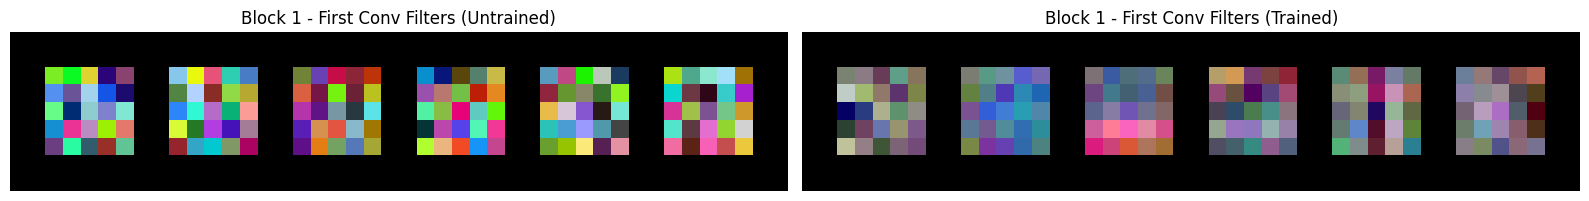

In [37]:
def visualize_filters(layer, title='Filters'):
    filters = layer.weight.data.clone().cpu()
    filters = (filters - filters.min()) / (filters.max() - filters.min())
    grid = vutils.make_grid(filters, nrow=8, padding=2)
    plt.figure(figsize=(8,8))
    plt.imshow(grid.permute(1, 2, 0))
    plt.title(title)
    plt.axis('off')
    plt.show()

model = ConvNet() # Untrained model

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# --- Untrained filters ---
# "features[0]" is your first convolutionnal layer, you might have to change it to conv1 if it was the name you gave it to
filters_untrained = model.conv1.weight.data.clone().cpu()
filters_untrained = (filters_untrained - filters_untrained.min()) / (filters_untrained.max() - filters_untrained.min())
grid_untrained = vutils.make_grid(filters_untrained, nrow=8, padding=2)
axes[0].imshow(grid_untrained.permute(1, 2, 0))
axes[0].set_title("Block 1 - First Conv Filters (Untrained)")
axes[0].axis("off")

# --- Trained filters ---
# Same thing here
filters_trained = net.conv1.weight.data.clone().cpu()
filters_trained = (filters_trained - filters_trained.min()) / (filters_trained.max() - filters_trained.min())
grid_trained = vutils.make_grid(filters_trained, nrow=8, padding=2)
axes[1].imshow(grid_trained.permute(1, 2, 0))
axes[1].set_title("Block 1 - First Conv Filters (Trained)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

#### What do you notice about the filters after the training ? Try to find an interpretation about it.

-> Answer :

We see that for the trained model, there seems to have a more coherent structure whereas the untrained one showcase some random patterns coming from the initialization. The first convolutional layer usually learns some low level features such as edges, color gradients, contours or corners, and deeper layers captures higher level features such as object or shape by combining the low level features. This comes from the fact that the deeper we go, the bigger the receptive field becomes, hence the portion of the image we bserve. 

Here I can't accurately understand what patterns the model learn for the first layer but we can see some boundaries on the 3rd (horizontal) and 5th channel (vertical). And also the first, second and last seems to have learn some color gradient. 

### Activation maps
This code snippet uses a forward hook to capture the output of the first convolutional layer of a CNN when a sample image is passed through it. The resulting activation maps show how each filter in the layer responds to different regions or features in the image.

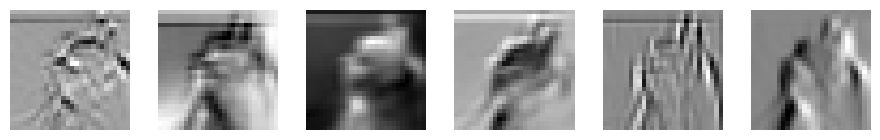

In [43]:
def get_activation(model, layer, x):
    activation = {}
    def hook_fn(module, input, output):
        activation['output'] = output.detach().cpu()
    hook = layer.register_forward_hook(hook_fn)
    model(x)
    hook.remove()
    return activation['output']

data_iter = iter(trainloader)
sample_images, sample_labels = next(data_iter)
sample_img = sample_images[30].unsqueeze(0).to(device)

# Get the feature maps after the first convolution (for example)
activation = get_activation(net, net.conv1, sample_img)

# Visualize a few feature maps in RGB:
def plot_feature_maps(feature_maps, n_cols=8):
    n_features = feature_maps.shape[1]
    n_rows = (n_features + n_cols - 1) // n_cols
    plt.figure(figsize=(n_cols * 1.5, n_rows * 1.5))
    for i in range(n_features):
        plt.subplot(n_rows, n_cols, i + 1)
        # Extract the i-th feature map from the first (and only) sample in the batch
        act = feature_maps[0, i, :, :]
        # Normalize the activation map to [0, 1]
        act_norm = (act - act.min()) / (act.max() - act.min() + 1e-8)
        # Repeat the single channel 3 times to form an RGB image
        act_rgb = act_norm.unsqueeze(0).repeat(3, 1, 1)
        plt.imshow(act_rgb.permute(1, 2, 0))
        plt.axis('off')
    plt.tight_layout()
    plt.show()

plot_feature_maps(activation, n_cols=8)

# Play with the index of the chosen sample to notice more patterns and answer the question

-> Answer :

The activation map helps us understand more the pattern our first layer learned as the response on the filter over the imageis highlighted in lighter colors. 
- The first, second and last filters seems to have capture big change in color in the image.
- The third one as previously seen captures edges and more accurately horizontal one, where the fifth seems to have captured vertical edges.
- The fourth filter is less clear but seems to have capture sometexture in the image. 